In [ ]:
!pip install torch tqdm matplotlib scikit-learn ipywidgets

# RAG 임베딩 모델 — 처음부터 만들기

> **Bi-Encoder** 구조의 임베딩 모델을 PyTorch로 직접 구현하고 학습합니다.

| 구성 요소 | 내용 |
|---|---|
| 인코더 | Transformer (Pre-LN, 2 layers, 4 heads) |
| 풀링 | Mean Pooling + L2 정규화 |
| 손실 함수 | InfoNCE (in-batch negatives) |
| 데이터 | 합성 데이터 (다운로드 불필요) |
| 평가 | MRR@10, Recall@{1,5,10} |

**실행 환경:** CPU에서 에폭당 약 2~4분 소요

## 1단계. 라이브러리 임포트

In [20]:
import math
import random
from dataclasses import dataclass, asdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 진행률 표시 (Jupyter 전용)
from tqdm.notebook import tqdm

print('PyTorch 버전 :', torch.__version__)
print('사용 디바이스 :', 'cuda' if torch.cuda.is_available() else 'cpu')


PyTorch 버전 : 2.10.0+cpu
사용 디바이스 : cpu


## 2단계. 하이퍼파라미터 설정

강의용 소형 모델 기준입니다. 파라미터를 바꿔가며 실험해보세요.

| 파라미터 | 강의용 | 풀 사이즈 | 설명 |
|---|---|---|---|
| `d_model` | 128 | 512 | Transformer hidden 차원 |
| `n_layers` | 2 | 6 | 레이어(블록) 수 |
| `n_heads` | 4 | 8 | Attention 헤드 수 |
| `d_ff` | 256 | 2048 | FFN 내부 차원 |
| `embed_dim` | 64 | 256 | 최종 출력 임베딩 차원 |
| `max_seq_len` | 32 | 128 | 최대 토큰 길이 (Attention은 길이²에 비례) |

In [21]:
# ──────────────────────────────────────────
# 모델 구조 설정
# ──────────────────────────────────────────
@dataclass
class ModelConfig:
    vocab_size : int   = 30_522  # 어휘 사전 크기 (BERT WordPiece 기준)
    max_seq_len: int   = 32      # 최대 입력 토큰 수 (짧을수록 빠름)
    d_model    : int   = 128     # Transformer 내부 차원
    n_heads    : int   = 4       # Multi-Head Attention 헤드 수
    n_layers   : int   = 2       # Transformer 레이어 수
    d_ff       : int   = 256     # FFN(Feed-Forward Network) 내부 차원
    dropout    : float = 0.1     # 드롭아웃 비율
    embed_dim  : int   = 64      # 최종 임베딩 벡터 차원

# ──────────────────────────────────────────
# 학습 설정
# ──────────────────────────────────────────
@dataclass
class TrainConfig:
    batch_size   : int   = 16      # 배치 크기 (클수록 더 많은 in-batch negative)
    learning_rate: float = 2e-4    # 학습률
    warmup_steps : int   = 100     # LR 워밍업 스텝 수
    epochs       : int   = 5       # 전체 학습 에폭 수
    temperature  : float = 0.05    # InfoNCE 온도 τ (낮을수록 강한 대조)
    max_grad_norm: float = 1.0     # Gradient clipping 임계값
    eval_every   : int   = 50      # N 스텝마다 검증 수행
    synthetic_n  : int   = 2_000   # 합성 데이터 쌍 수
    save_path    : str   = 'embedding_model.pt'
    device       : str   = 'cuda' if torch.cuda.is_available() else 'cpu'

model_cfg = ModelConfig()
train_cfg = TrainConfig()

print(f'디바이스  : {train_cfg.device}')
print(f'd_model   : {model_cfg.d_model}')
print(f'n_layers  : {model_cfg.n_layers}')
print(f'embed_dim : {model_cfg.embed_dim}')


디바이스  : cpu
d_model   : 128
n_layers  : 2
embed_dim : 64


## 3단계. 토크나이저

다운로드 없이 바로 사용할 수 있는 **화이트스페이스 토크나이저**입니다.

실제 서비스에서는 BERT WordPiece 또는 BPE 토크나이저를 사용하지만,
개념 학습 목적으로는 이 간단한 버전으로 충분합니다.

```
입력 텍스트: "What is gradient descent?"
    ↓
[CLS] what is gradient descent ? [SEP] [PAD] [PAD] ...
    ↓
input_ids:      [2, 10, 11, 12, 13, 14, 3, 0, 0, ...]
attention_mask: [1,  1,  1,  1,  1,  1, 1, 0, 0, ...]
```

In [22]:
class SimpleTokenizer:
    """
    단어 단위 화이트스페이스 토크나이저.
    특수 토큰: [PAD]=0, [UNK]=1, [CLS]=2, [SEP]=3
    """
    PAD, UNK, CLS, SEP = 0, 1, 2, 3

    def __init__(self, max_seq_len=32):
        self.max_seq_len = max_seq_len
        # 특수 토큰으로 어휘 사전 초기화
        self.word2id = {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3}
        self.next_id = 4

    def _get_id(self, word):
        """단어 → ID 변환 (없으면 새로 추가)"""
        if word not in self.word2id:
            self.word2id[word] = self.next_id
            self.next_id += 1
        return self.word2id[word]

    def encode(self, text):
        """
        텍스트를 토큰 ID 시퀀스로 변환.
        - 앞에 [CLS], 뒤에 [SEP] 추가
        - max_seq_len에 맞게 패딩 또는 잘라내기
        """
        # 소문자 변환 후 단어 단위 분리
        word_ids = [self._get_id(w.lower()) for w in text.split()]

        # [CLS] + 내용 토큰 + [SEP] 구성 (최대 길이에 맞게 자름)
        tokens = [self.CLS] + word_ids[:self.max_seq_len - 2] + [self.SEP]

        # 나머지 자리를 [PAD]로 채움
        pad_len = self.max_seq_len - len(tokens)
        input_ids      = tokens + [self.PAD] * pad_len
        attention_mask = [1] * len(tokens) + [0] * pad_len  # 1=실제토큰, 0=패딩

        return {
            'input_ids'     : torch.tensor(input_ids,      dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        }

    @property
    def vocab_size(self):
        """현재까지 등록된 어휘 수 반환"""
        return max(30_522, self.next_id)


# 토크나이저 생성 및 동작 확인
tokenizer = SimpleTokenizer(max_seq_len=model_cfg.max_seq_len)

sample = tokenizer.encode('What is gradient descent?')
print('input_ids      :', sample['input_ids'].tolist())
print('attention_mask :', sample['attention_mask'].tolist())
print(f'시퀀스 길이     : {len(sample["input_ids"])} (max_seq_len={model_cfg.max_seq_len})')


input_ids      : [2, 4, 5, 6, 7, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask : [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
시퀀스 길이     : 32 (max_seq_len=32)


## 4단계. 모델 아키텍처

세 개의 모듈로 구성됩니다.

```
입력 텍스트
    ↓
[TokenEmbedding]  토큰 임베딩 + 위치 임베딩
    ↓
[TransformerEncoderLayer] × N  (Pre-LN 구조)
    Self-Attention → LayerNorm → FFN
    ↓
[Mean Pooling]  패딩 제외하고 평균
    ↓
[Projection Head]  Linear → GELU → Linear
    ↓
[L2 Normalize]  코사인 유사도 = 내적 가능하게
    ↓
임베딩 벡터 (크기: embed_dim)
```

In [23]:
# ──────────────────────────────────────────
# 4-1. 토큰 임베딩 + 위치 임베딩
# ──────────────────────────────────────────
class TokenEmbedding(nn.Module):
    """
    두 종류의 임베딩을 더해서 입력 표현을 만듭니다.
    - token_emb : 각 단어의 의미 벡터
    - pos_emb   : 시퀀스 내 위치 정보 (사인/코사인 초기화)
    """
    def __init__(self, cfg):
        super().__init__()
        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.d_model, padding_idx=0)
        self.pos_emb   = nn.Embedding(cfg.max_seq_len, cfg.d_model)
        self.norm = nn.LayerNorm(cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)

        # 위치 임베딩을 사인/코사인 패턴으로 초기화 (학습 안정성 향상)
        pos = torch.arange(cfg.max_seq_len).unsqueeze(1)      # (L, 1)
        dim = torch.arange(0, cfg.d_model, 2)                 # (d/2,)
        pe  = torch.zeros(cfg.max_seq_len, cfg.d_model)
        pe[:, 0::2] = torch.sin(pos / 10000 ** (dim / cfg.d_model))  # 짝수 차원
        pe[:, 1::2] = torch.cos(pos / 10000 ** (dim / cfg.d_model))  # 홀수 차원
        self.pos_emb.weight.data.copy_(pe)

    def forward(self, input_ids):
        B, L = input_ids.shape
        # 위치 인덱스 생성 (0, 1, 2, ..., L-1)
        positions = torch.arange(L, device=input_ids.device).unsqueeze(0)  # (1, L)
        # 토큰 임베딩 + 위치 임베딩 합산 후 정규화
        x = self.token_emb(input_ids) + self.pos_emb(positions)  # (B, L, d_model)
        return self.drop(self.norm(x))


In [24]:
# ──────────────────────────────────────────
# 4-2. Transformer 인코더 레이어 (Pre-LN)
# ──────────────────────────────────────────
class TransformerEncoderLayer(nn.Module):
    """
    Pre-LayerNorm Transformer 블록.

    Post-LN (원래 논문) 대신 Pre-LN을 사용하면
    학습 초기 gradient 폭발/소실 문제가 줄어듭니다.

    구조:
        x → LayerNorm → MultiHeadAttention → Dropout → + (residual)
          → LayerNorm → FFN               → Dropout → + (residual)
    """
    def __init__(self, cfg):
        super().__init__()
        # Multi-Head Self-Attention
        # batch_first=True: 입력 형태 (B, L, D) — PyTorch 기본은 (L, B, D)
        self.attn  = nn.MultiheadAttention(
            cfg.d_model, cfg.n_heads, dropout=cfg.dropout, batch_first=True
        )
        # Feed-Forward Network: d_model → d_ff → d_model
        self.ff    = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_ff),
            nn.GELU(),           # ReLU보다 부드러운 활성화 함수
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_ff, cfg.d_model),
        )
        self.norm1 = nn.LayerNorm(cfg.d_model)  # Attention 전 정규화
        self.norm2 = nn.LayerNorm(cfg.d_model)  # FFN 전 정규화
        self.drop  = nn.Dropout(cfg.dropout)

    def forward(self, x, key_padding_mask):
        # ── Self-Attention (Pre-LN) ──────────────────
        residual = x
        x = self.norm1(x)   # 먼저 정규화
        # key_padding_mask: True인 위치(패딩)는 Attention에서 무시
        x, _ = self.attn(x, x, x, key_padding_mask=key_padding_mask)
        x = self.drop(x) + residual  # Residual connection

        # ── Feed-Forward (Pre-LN) ────────────────────
        residual = x
        x = self.norm2(x)   # 먼저 정규화
        x = self.ff(x)
        x = self.drop(x) + residual  # Residual connection
        return x


In [25]:
# ──────────────────────────────────────────
# 4-3. 전체 임베딩 모델
# ──────────────────────────────────────────
class EmbeddingModel(nn.Module):
    """
    Bi-Encoder 임베딩 모델.

    Query와 Passage 모두 동일한 가중치(Shared Encoder)로 인코딩합니다.
    출력은 L2 정규화된 고정 크기 벡터 → 코사인 유사도 = 두 벡터의 내적

    입력:
        input_ids      : (B, L) 토큰 ID
        attention_mask : (B, L) 실제 토큰=1, 패딩=0
    출력:
        embeddings     : (B, embed_dim) L2 정규화된 임베딩
    """
    def __init__(self, cfg):
        super().__init__()
        self.embedding = TokenEmbedding(cfg)
        # N개의 Transformer 레이어를 쌓아 올림
        self.layers    = nn.ModuleList(
            [TransformerEncoderLayer(cfg) for _ in range(cfg.n_layers)]
        )
        # Projection Head: 임베딩 차원을 최종 크기로 변환
        self.proj = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.GELU(),
            nn.Linear(cfg.d_model, cfg.embed_dim),
        )

    def forward(self, input_ids, attention_mask):
        # 패딩 마스크: True인 위치를 Attention에서 무시
        key_padding_mask = (attention_mask == 0)  # (B, L)

        # 1. 임베딩 레이어
        x = self.embedding(input_ids)             # (B, L, d_model)

        # 2. N개의 Transformer 레이어 통과
        for layer in self.layers:
            x = layer(x, key_padding_mask)         # (B, L, d_model)

        # 3. Mean Pooling: 패딩 제외하고 실제 토큰만 평균
        #    attention_mask를 가중치로 사용해 패딩 위치를 0으로 만든 후 평균
        mask = attention_mask.unsqueeze(-1).float()   # (B, L, 1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)  # (B, d_model)

        # 4. Projection Head
        x = self.proj(x)                          # (B, embed_dim)

        # 5. L2 정규화: ||x|| = 1 → 코사인 유사도 = 내적
        return F.normalize(x, p=2, dim=-1)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# 모델 생성
model_cfg.vocab_size = tokenizer.vocab_size
model = EmbeddingModel(model_cfg).to(train_cfg.device)

print(f'총 파라미터 수 : {model.count_parameters():,}')
print(f'임베딩 차원    : {model_cfg.embed_dim}')

# 모델 구조 출력
print('\n모델 구조:')
print(model)


총 파라미터 수 : 4,200,896
임베딩 차원    : 64

모델 구조:
EmbeddingModel(
  (embedding): TokenEmbedding(
    (token_emb): Embedding(30522, 128, padding_idx=0)
    (pos_emb): Embedding(32, 128)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.1, inplace=False)
  )
  (layers): ModuleList(
    (0-1): 2 x TransformerEncoderLayer(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (proj): Sequential(
    (0): Linear(in_features=128, out_features=

## 5단계. InfoNCE 손실 함수

**In-batch negatives** 전략을 사용합니다.

배치 안의 다른 passage들이 자동으로 negative 샘플이 됩니다.
배치 크기가 클수록 더 많은 negative → 더 강한 학습 신호!

```
배치 크기 B=4일 때의 유사도 행렬:

             p0    p1    p2    p3
        q0 [✅   ❌    ❌    ❌ ]  ← q0는 p0가 정답
        q1 [❌   ✅    ❌    ❌ ]  ← q1는 p1가 정답
        q2 [❌   ❌    ✅    ❌ ]  ← q2는 p2가 정답
        q3 [❌   ❌    ❌    ✅ ]  ← q3는 p3가 정답

대각선=정답, 나머지=in-batch negative (공짜로 얻는 hard negative!)
```

손실 수식:
$$\mathcal{L} = -\log \frac{\exp(\text{sim}(q_i, p_i^+) / \tau)}{\sum_{j=1}^{B} \exp(\text{sim}(q_i, p_j) / \tau)}$$

In [26]:
class InfoNCELoss(nn.Module):
    """
    InfoNCE (Noise-Contrastive Estimation) 손실 함수.

    핵심 아이디어:
    - 같은 쌍(query, positive_passage)의 임베딩은 가까이
    - 다른 쌍(query, negative_passage)의 임베딩은 멀리

    온도 τ (temperature):
    - 낮을수록 (예: 0.05) → 확률 분포가 뾰족해짐 → 더 강한 학습 신호
    - 높을수록 (예: 0.5)  → 확률 분포가 평평해짐 → 학습이 부드러워짐
    """
    def __init__(self, temperature=0.05):
        super().__init__()
        self.temperature = temperature

    def forward(self, q_emb, p_emb):
        """
        q_emb: (B, D) — 쿼리 임베딩 (L2 정규화됨)
        p_emb: (B, D) — 정답 패시지 임베딩 (L2 정규화됨)
        """
        B = q_emb.size(0)

        # B×B 코사인 유사도 행렬 (L2 정규화 → 내적 = 코사인)
        # sim[i][j] = q_i와 p_j의 유사도
        sim = torch.matmul(q_emb, p_emb.T) / self.temperature  # (B, B)

        # 정답 레이블: 대각선 (q_i의 정답은 p_i)
        labels = torch.arange(B, device=q_emb.device)

        # Query→Passage 방향 손실
        loss_qp = F.cross_entropy(sim,   labels)
        # Passage→Query 방향 손실 (양방향 symmetric)
        loss_pq = F.cross_entropy(sim.T, labels)

        return (loss_qp + loss_pq) / 2


# 손실 함수 생성
criterion = InfoNCELoss(temperature=train_cfg.temperature)
print(f'InfoNCE 손실 함수 준비 완료 (temperature={train_cfg.temperature})')


InfoNCE 손실 함수 준비 완료 (temperature=0.05)


## 6단계. 데이터셋

다운로드 없이 바로 사용할 수 있는 **합성 (query, passage) 쌍**을 생성합니다.

각 쌍은 같은 개념을 묻는 질문(query)과 그 개념을 설명하는 문장(passage)으로 구성됩니다.

> 💡 실제 RAG 학습에는 MS MARCO, NQ(Natural Questions), HotpotQA 등의
> 공개 데이터셋을 사용합니다.

In [27]:
class TripletDataset(Dataset):
    """
    (query, positive_passage) 쌍으로 구성된 데이터셋.
    Negative는 배치 내에서 자동으로 샘플링됩니다 (in-batch negatives).
    """
    def __init__(self, pairs, tokenizer):
        self.pairs     = pairs
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        # 쿼리와 패시지를 각각 토큰화
        q = self.tokenizer.encode(item['query'])
        p = self.tokenizer.encode(item['positive'])
        return {
            'q_input_ids'     : q['input_ids'],
            'q_attention_mask': q['attention_mask'],
            'p_input_ids'     : p['input_ids'],
            'p_attention_mask': p['attention_mask'],
        }


def make_synthetic_pairs(n=2_000):
    """
    (query, positive_passage) 합성 데이터 생성.
    다양한 주제의 질문-답변 패턴으로 구성됩니다.
    """
    # 질문-답변 템플릿 쌍
    templates = [
        ('What is {concept}?',
         '{concept} is a core concept in {field} that involves {detail}.'),
        ('How does {concept} work?',
         'The mechanism of {concept} relies on {detail}, used in {field}.'),
        ('Why is {concept} important in {field}?',
         '{concept} is critical in {field} because it enables {detail}.'),
        ('Explain {concept} in {field}.',
         'In {field}, {concept} refers to {detail}, which is fundamental.'),
        ('What role does {concept} play in {field}?',
         '{concept} plays a key role in {field} by providing {detail}.'),
    ]

    # (개념, 분야, 핵심 설명) 목록
    concepts = [
        ('gradient descent',     'machine learning',     'minimizing loss via negative gradient steps'),
        ('attention mechanism',  'NLP',                  'computing weighted sums over token vectors'),
        ('backpropagation',      'deep learning',        'computing gradients via the chain rule'),
        ('CRISPR',               'genomics',             'targeted DNA editing with guide RNA'),
        ('Fourier transform',    'signal processing',    'decomposing signals into frequencies'),
        ('transformer model',    'deep learning',        'self-attention and feedforward stacking'),
        ('RAG',                  'NLP',                  'augmenting LLMs with retrieved documents'),
        ('contrastive learning', 'self-supervised ML',   'pulling similar pairs close in embedding space'),
        ('mean pooling',         'NLP',                  'averaging token embeddings for a sentence vector'),
        ('cosine similarity',    'information retrieval','measuring angle between two vectors'),
        ('dropout',              'deep learning',        'randomly zeroing activations during training'),
        ('layer normalization',  'deep learning',        'normalizing activations within each layer'),
        ('beam search',          'NLP',                  'exploring top-k sequences at each decoding step'),
        ('word embeddings',      'NLP',                  'mapping words to dense vector representations'),
        ('fine-tuning',          'transfer learning',    'adapting a pretrained model on a small dataset'),
    ]

    pairs = []
    for _ in range(n):
        q_tmpl, p_tmpl = random.choice(templates)
        concept, field, detail = random.choice(concepts)
        pairs.append({
            'query'   : q_tmpl.format(concept=concept, field=field, detail=detail),
            'positive': p_tmpl.format(concept=concept, field=field, detail=detail),
        })
    return pairs


# ── 데이터 생성 및 분할 ─────────────────────────────────
print(f'합성 데이터 {train_cfg.synthetic_n:,}쌍 생성 중...')
all_pairs = make_synthetic_pairs(train_cfg.synthetic_n)

# 95% 학습 / 5% 검증 분할
split      = int(0.95 * len(all_pairs))
train_pairs = all_pairs[:split]
val_pairs   = all_pairs[split:]
print(f'학습 데이터: {len(train_pairs):,}쌍')
print(f'검증 데이터: {len(val_pairs):,}쌍')

# Dataset & DataLoader 생성
train_dataset = TripletDataset(train_pairs, tokenizer)
val_dataset   = TripletDataset(val_pairs,   tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=train_cfg.batch_size,
    shuffle=True,    # 매 에폭마다 순서 섞기
    num_workers=0,   # Windows/Jupyter 호환성을 위해 0 사용
)
val_loader = DataLoader(
    val_dataset,
    batch_size=train_cfg.batch_size * 2,
    shuffle=False,
    num_workers=0,
)

# 어휘 사전 크기 업데이트 (데이터 토큰화 후 vocab이 늘어남)
model_cfg.vocab_size = tokenizer.vocab_size
print(f'\n어휘 사전 크기: {tokenizer.vocab_size:,}')
print(f'배치 수 (학습): {len(train_loader)}')


합성 데이터 2,000쌍 생성 중...
학습 데이터: 1,900쌍
검증 데이터: 100쌍

어휘 사전 크기: 30,522
배치 수 (학습): 119


## 7단계. 옵티마이저 & 학습률 스케줄러

**선형 워밍업 + 코사인 감쇠** 스케줄을 사용합니다.

```
학습률
  ↑
  │     /\
  │    /  \___
  │   /        \___
  │  /              \___
  │ /                    \___
  └─────────────────────────→ 스텝
    워밍업    코사인 감쇠
```

In [28]:
# ── 옵티마이저 ──────────────────────────────────────────
# AdamW: Adam + Weight Decay (L2 정규화 방식 개선)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=train_cfg.learning_rate,
    weight_decay=0.01,  # 가중치 감쇠로 과적합 방지
)

# ── 학습률 스케줄러 ──────────────────────────────────────
total_steps = len(train_loader) * train_cfg.epochs

def lr_lambda(current_step):
    """워밍업 구간: 선형 증가 / 이후: 코사인 감쇠"""
    if current_step < train_cfg.warmup_steps:
        # 워밍업: 0 → 1.0 선형 증가
        return current_step / max(1, train_cfg.warmup_steps)
    # 코사인 감쇠: 1.0 → 0.0
    progress = (current_step - train_cfg.warmup_steps) / max(1, total_steps - train_cfg.warmup_steps)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f'총 학습 스텝 수 : {total_steps}')
print(f'워밍업 스텝 수  : {train_cfg.warmup_steps}')
print(f'최대 학습률     : {train_cfg.learning_rate}')


총 학습 스텝 수 : 595
워밍업 스텝 수  : 100
최대 학습률     : 0.0002


## 8단계. 평가 함수

**MRR@10** (Mean Reciprocal Rank)과 **Recall@K**를 계산합니다.

- **MRR@10**: 정답 패시지의 순위가 얼마나 높은지 (1이 최고)
- **Recall@K**: 상위 K개 안에 정답이 들어있는 비율

In [29]:
@torch.no_grad()  # 평가 시에는 gradient 계산 불필요
def evaluate(model, val_loader, device):
    """
    검증 데이터 전체에 대해 MRR@10, Recall@{1,5,10}을 계산합니다.

    방법:
    1. 모든 query와 passage를 임베딩
    2. N×N 유사도 행렬 계산
    3. 각 query의 정답 passage 순위 계산 (대각선이 정답)
    """
    model.eval()
    all_q_embs, all_p_embs = [], []

    for batch in val_loader:
        # 쿼리 임베딩
        q_emb = model(
            batch['q_input_ids'].to(device),
            batch['q_attention_mask'].to(device),
        )
        # 패시지 임베딩
        p_emb = model(
            batch['p_input_ids'].to(device),
            batch['p_attention_mask'].to(device),
        )
        all_q_embs.append(q_emb.cpu())
        all_p_embs.append(p_emb.cpu())

    Q = torch.cat(all_q_embs)  # (N, embed_dim)
    P = torch.cat(all_p_embs)  # (N, embed_dim)

    # N×N 코사인 유사도 행렬
    sim = torch.matmul(Q, P.T)  # (N, N)

    # 각 query의 정답 passage 순위 계산
    # (sim > 정답유사도).sum() + 1 = 정답의 순위
    ranks = (sim > sim.diagonal().unsqueeze(1)).sum(dim=1) + 1  # 1-indexed

    model.train()
    return {
        'MRR@10': (1.0 / ranks.float()).mean().item(),
        'R@1'   : (ranks <= 1).float().mean().item(),
        'R@5'   : (ranks <= 5).float().mean().item(),
        'R@10'  : (ranks <= 10).float().mean().item(),
    }


# 학습 전 초기 성능 확인
print('학습 전 초기 성능:')
init_metrics = evaluate(model, val_loader, train_cfg.device)
for k, v in init_metrics.items():
    print(f'  {k:8s}: {v:.4f}')
print('(무작위 수준 — 학습 후 개선되어야 정상입니다)')


학습 전 초기 성능:
  MRR@10  : 0.1947
  R@1     : 0.0900
  R@5     : 0.3100
  R@10    : 0.4800
(무작위 수준 — 학습 후 개선되어야 정상입니다)


## 9단계. 학습 실행 🚀

> ⏱ CPU 기준 에폭당 약 **2~4분** 소요됩니다.

In [30]:
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Korean font setup (Windows)
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

device       = train_cfg.device
step         = 0
best_mrr     = 0.0
train_losses = []   # 스텝별 손실값 기록
eval_records = []   # 평가 결과 기록

for epoch in range(1, train_cfg.epochs + 1):
    model.train()
    epoch_loss = 0.0

    # tqdm으로 진행률 표시
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{train_cfg.epochs}', leave=True)

    for batch in pbar:
        # ── 배치 데이터를 디바이스로 이동 ──────────────
        q_ids  = batch['q_input_ids'].to(device)
        q_mask = batch['q_attention_mask'].to(device)
        p_ids  = batch['p_input_ids'].to(device)
        p_mask = batch['p_attention_mask'].to(device)

        # ── Forward pass ────────────────────────────────
        optimizer.zero_grad()             # gradient 초기화
        q_emb = model(q_ids, q_mask)     # 쿼리 임베딩 (B, D)
        p_emb = model(p_ids, p_mask)     # 패시지 임베딩 (B, D)
        loss  = criterion(q_emb, p_emb)  # InfoNCE 손실 계산

        # ── Backward pass ───────────────────────────────
        loss.backward()                  # gradient 계산
        # Gradient clipping: 너무 큰 gradient를 잘라내어 학습 안정화
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg.max_grad_norm)
        optimizer.step()                 # 가중치 업데이트
        scheduler.step()                 # 학습률 업데이트

        step       += 1
        epoch_loss += loss.item()
        train_losses.append(loss.item())

        # tqdm 진행바에 현재 손실 표시
        pbar.set_postfix(
            loss=f'{loss.item():.4f}',
            lr=f'{scheduler.get_last_lr()[0]:.2e}',
        )

        # ── 주기적 평가 ─────────────────────────────────
        if step % train_cfg.eval_every == 0:
            metrics = evaluate(model, val_loader, device)
            eval_records.append({'step': step, **metrics})
            mrr = metrics['MRR@10']
            print(f'Step {step:4d} | ' + ' | '.join(f'{k}: {v:.4f}' for k, v in metrics.items()))

            # 최고 성능 모델 저장
            if mrr > best_mrr:
                best_mrr = mrr
                torch.save(
                    {'model_state': model.state_dict(), 'config': asdict(model_cfg)},
                    train_cfg.save_path,
                )
                print(f'  → Best model 저장! (MRR@10={best_mrr:.4f})')

    avg_loss = epoch_loss / len(train_loader)
    print(f'Epoch {epoch} 완료 | 평균 손실: {avg_loss:.4f}\n')

print(f'학습 완료! Best MRR@10: {best_mrr:.4f}')
print(f'모델 저장 위치: {train_cfg.save_path}')


Epoch 1/5:   0%|          | 0/119 [00:00<?, ?it/s]

Step   50 | MRR@10: 0.8296 | R@1: 0.7600 | R@5: 0.9000 | R@10: 0.9700
  → Best model 저장! (MRR@10=0.8296)
Step  100 | MRR@10: 0.9808 | R@1: 0.9700 | R@5: 1.0000 | R@10: 1.0000
  → Best model 저장! (MRR@10=0.9808)
Epoch 1 완료 | 평균 손실: 1.0216



Epoch 2/5:   0%|          | 0/119 [00:00<?, ?it/s]

Step  150 | MRR@10: 0.9733 | R@1: 0.9500 | R@5: 1.0000 | R@10: 1.0000
Step  200 | MRR@10: 0.9875 | R@1: 0.9800 | R@5: 1.0000 | R@10: 1.0000
  → Best model 저장! (MRR@10=0.9875)
Epoch 2 완료 | 평균 손실: 0.1882



Epoch 3/5:   0%|          | 0/119 [00:00<?, ?it/s]

Step  250 | MRR@10: 0.9775 | R@1: 0.9600 | R@5: 1.0000 | R@10: 1.0000
Step  300 | MRR@10: 0.9858 | R@1: 0.9800 | R@5: 1.0000 | R@10: 1.0000
Step  350 | MRR@10: 0.9875 | R@1: 0.9800 | R@5: 1.0000 | R@10: 1.0000
Epoch 3 완료 | 평균 손실: 0.1505



Epoch 4/5:   0%|          | 0/119 [00:00<?, ?it/s]

Step  400 | MRR@10: 0.9875 | R@1: 0.9800 | R@5: 1.0000 | R@10: 1.0000
Step  450 | MRR@10: 0.9783 | R@1: 0.9600 | R@5: 1.0000 | R@10: 1.0000
Epoch 4 완료 | 평균 손실: 0.1622



Epoch 5/5:   0%|          | 0/119 [00:00<?, ?it/s]

Step  500 | MRR@10: 0.9750 | R@1: 0.9500 | R@5: 1.0000 | R@10: 1.0000
Step  550 | MRR@10: 0.9700 | R@1: 0.9400 | R@5: 1.0000 | R@10: 1.0000
Epoch 5 완료 | 평균 손실: 0.1641

학습 완료! Best MRR@10: 0.9875
모델 저장 위치: embedding_model.pt


## 10단계. 학습 곡선 시각화

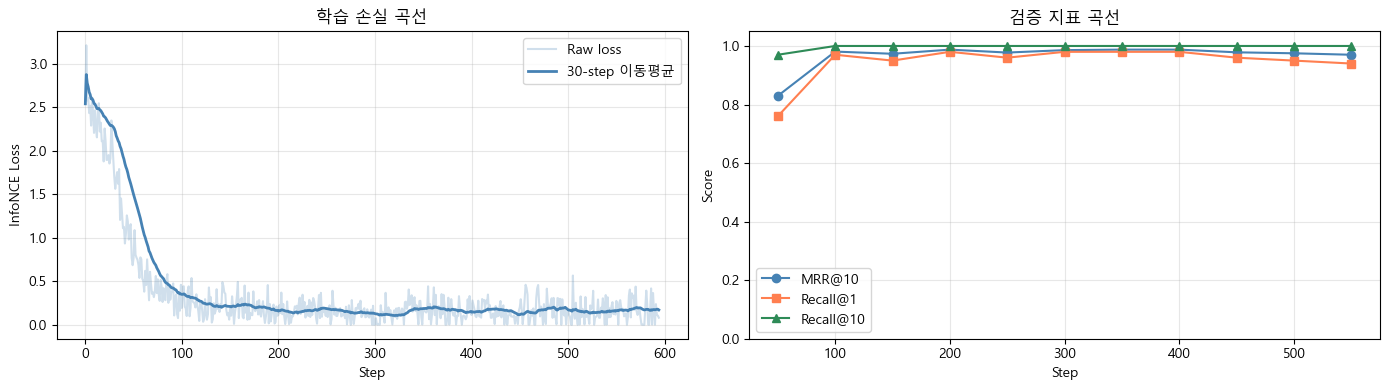

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── 왼쪽: 손실 곡선 ───────────────────────────────────
window   = min(30, len(train_losses) // 5 + 1)
smoothed = [
    sum(train_losses[max(0, i-window):i+1]) / len(train_losses[max(0, i-window):i+1])
    for i in range(len(train_losses))
]
axes[0].plot(train_losses, alpha=0.25, color='steelblue', label='Raw loss')
axes[0].plot(smoothed,     color='steelblue', linewidth=2, label=f'{window}-step 이동평균')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('InfoNCE Loss')
axes[0].set_title('학습 손실 곡선')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── 오른쪽: 평가 지표 곡선 ────────────────────────────
if eval_records:
    steps   = [r['step']    for r in eval_records]
    mrr     = [r['MRR@10'] for r in eval_records]
    r1      = [r['R@1']    for r in eval_records]
    r10     = [r['R@10']   for r in eval_records]
    axes[1].plot(steps, mrr, 'o-', label='MRR@10',  color='steelblue')
    axes[1].plot(steps, r1,  's-', label='Recall@1', color='coral')
    axes[1].plot(steps, r10, '^-', label='Recall@10',color='seagreen')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Score')
    axes[1].set_title('검증 지표 곡선')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


## 11단계. 최종 평가

In [32]:
# 저장된 최선 모델 불러오기
checkpoint = torch.load(train_cfg.save_path, map_location=train_cfg.device, weights_only=True)
model.load_state_dict(checkpoint['model_state'])
print('Best model 로드 완료')

# 최종 성능 측정
final_metrics = evaluate(model, val_loader, train_cfg.device)

print('\n최종 검증 결과:')
print('-' * 40)
for k, v in final_metrics.items():
    bar = '█' * int(v * 30)
    print(f'  {k:8s}: {v:.4f}  {bar}')
print('-' * 40)
print(f'  Best MRR@10: {best_mrr:.4f}')


Best model 로드 완료

최종 검증 결과:
----------------------------------------
  MRR@10  : 0.9875  █████████████████████████████
  R@1     : 0.9800  █████████████████████████████
  R@5     : 1.0000  ██████████████████████████████
  R@10    : 1.0000  ██████████████████████████████
----------------------------------------
  Best MRR@10: 0.9875


## 12단계. RAG 검색 데모 🔍

학습된 모델로 실제 검색을 수행합니다.

1. Passage 풀을 임베딩하여 인덱스 구축
2. 쿼리를 임베딩한 후 코사인 유사도로 가장 가까운 passage 반환

In [33]:
class RAGRetriever:
    """
    학습된 임베딩 모델을 이용한 간단한 RAG 검색기.

    사용법:
        retriever = RAGRetriever(model, tokenizer)
        retriever.index(passages)         # passage 풀 인덱싱
        results = retriever.search(query) # 쿼리로 검색
    """
    def __init__(self, model, tokenizer, device='cpu'):
        self.model     = model.eval().to(device)
        self.tokenizer = tokenizer
        self.device    = device
        self._index    = None   # (N, D) 임베딩 행렬
        self._passages = []     # 원본 텍스트 목록

    @torch.no_grad()
    def _embed(self, texts):
        """텍스트 리스트를 임베딩 행렬로 변환"""
        embs = []
        for text in texts:
            enc = self.tokenizer.encode(text)
            emb = self.model(
                enc['input_ids'].unsqueeze(0).to(self.device),
                enc['attention_mask'].unsqueeze(0).to(self.device),
            )
            embs.append(emb)
        return torch.cat(embs, dim=0)  # (N, D)

    def index(self, passages):
        """Passage 풀을 임베딩하여 검색 인덱스 구축"""
        print(f'인덱싱 중... ({len(passages)}개 passage)')
        self._passages = passages
        self._index    = self._embed(passages)
        print('인덱스 구축 완료!')

    def search(self, query, top_k=3):
        """쿼리와 가장 유사한 passage top_k개를 반환"""
        if self._index is None:
            raise RuntimeError('먼저 .index()를 실행하세요.')
        q_emb  = self._embed([query])                    # (1, D)
        scores = (q_emb @ self._index.T).squeeze(0)     # (N,)
        top_ids = scores.topk(top_k).indices.tolist()
        return [
            {'rank': i+1, 'score': scores[idx].item(), 'passage': self._passages[idx]}
            for i, idx in enumerate(top_ids)
        ]


# ── 검색 데모 실행 ────────────────────────────────────────
demo_passages = [
    'Gradient descent minimizes a function by stepping in the negative gradient direction.',
    'Attention mechanisms compute weighted sums of value vectors based on query-key similarity.',
    'CRISPR-Cas9 enables precise editing of genomic DNA sequences using guide RNAs.',
    'RAG enhances LLMs by retrieving relevant documents at inference time.',
    'Contrastive learning trains models to pull similar pairs close in embedding space.',
    'Mean pooling averages all token embeddings to produce a fixed-size sentence vector.',
    'Cosine similarity measures the angle between two vectors regardless of magnitude.',
    'Backpropagation computes gradients through a neural network using the chain rule.',
    'Dropout randomly zeros activations during training to prevent overfitting.',
    'Layer normalization stabilizes training by normalizing activations within a layer.',
]

retriever = RAGRetriever(model, tokenizer, device=train_cfg.device)
retriever.index(demo_passages)

# 검색 테스트
test_queries = [
    'how does the attention mechanism work?',
    'what is retrieval augmented generation?',
    'explain gradient optimization technique',
    'how to prevent overfitting in neural networks?',
]

print('\n' + '='*60)
for query in test_queries:
    print(f'\n쿼리: "{query}"')
    print('-' * 50)
    results = retriever.search(query, top_k=3)
    for r in results:
        print(f'  [{r["rank"]}위] 유사도={r["score"]:.4f}')
        print(f'       {r["passage"]}')
print('\n' + '='*60)


인덱싱 중... (10개 passage)
인덱스 구축 완료!


쿼리: "how does the attention mechanism work?"
--------------------------------------------------
  [1위] 유사도=0.5814
       Attention mechanisms compute weighted sums of value vectors based on query-key similarity.
  [2위] 유사도=0.3374
       CRISPR-Cas9 enables precise editing of genomic DNA sequences using guide RNAs.
  [3위] 유사도=0.3210
       Contrastive learning trains models to pull similar pairs close in embedding space.

쿼리: "what is retrieval augmented generation?"
--------------------------------------------------
  [1위] 유사도=0.2731
       Attention mechanisms compute weighted sums of value vectors based on query-key similarity.
  [2위] 유사도=0.2233
       Layer normalization stabilizes training by normalizing activations within a layer.
  [3위] 유사도=0.1054
       Gradient descent minimizes a function by stepping in the negative gradient direction.

쿼리: "explain gradient optimization technique"
--------------------------------------------------
  [1위] 유사

## 13단계. 임베딩 공간 시각화 (보너스)

PCA로 고차원 임베딩을 2D로 축소하여 시각화합니다.

잘 학습된 모델이라면 같은 주제의 query와 passage가 가까이 모여야 합니다.

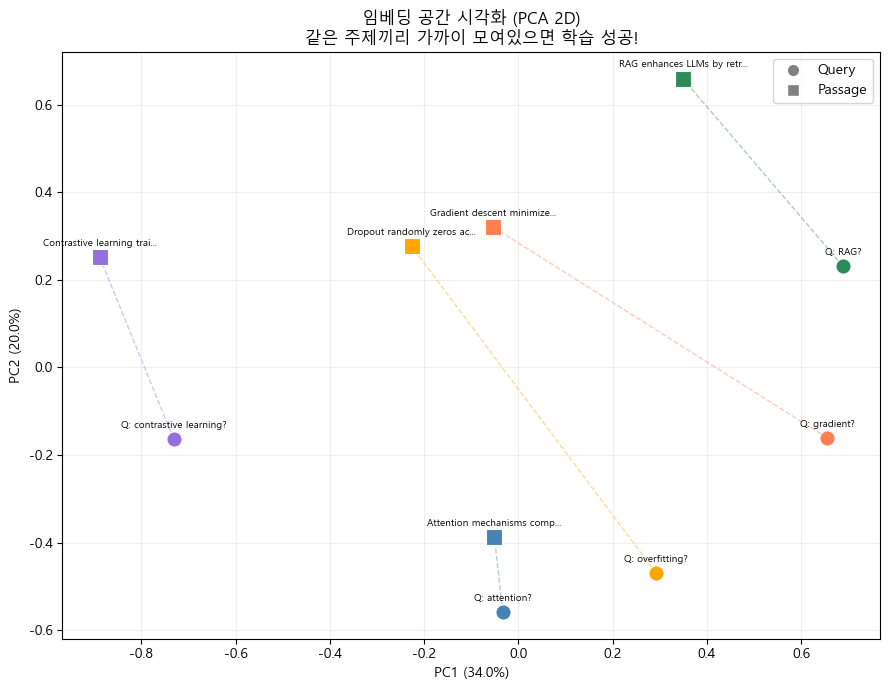

In [34]:
from sklearn.decomposition import PCA  # pip install scikit-learn

# 시각화할 샘플 데이터 (query-passage 쌍)
viz_data = [
    ('Q: attention?',           demo_passages[1], 'attention'),
    ('Q: gradient?',            demo_passages[0], 'gradient'),
    ('Q: RAG?',                 demo_passages[3], 'RAG'),
    ('Q: contrastive learning?',demo_passages[4], 'contrastive'),
    ('Q: overfitting?',         demo_passages[8], 'dropout'),
]

texts  = [t  for t, p, _ in viz_data] + [p  for _, p, _ in viz_data]
labels = [lbl for _, _, lbl in viz_data] + [lbl for _, _, lbl in viz_data]
kinds  = ['query'] * len(viz_data) + ['passage'] * len(viz_data)

# 임베딩 계산
with torch.no_grad():
    embs = retriever._embed(texts).cpu().numpy()

# PCA로 2D 축소
pca  = PCA(n_components=2)
xy   = pca.fit_transform(embs)

# 시각화
colors = {'attention':'steelblue', 'gradient':'coral', 'RAG':'seagreen',
          'contrastive':'mediumpurple', 'dropout':'orange'}

plt.figure(figsize=(9, 7))
for i, (x, y) in enumerate(xy):
    color  = colors[labels[i]]
    marker = 'o' if kinds[i] == 'query' else 's'
    plt.scatter(x, y, c=color, marker=marker, s=120,
                edgecolors='white', linewidths=0.8, zorder=3)
    # Query-Passage 연결선
    if kinds[i] == 'query':
        pair_idx = i + len(viz_data)
        px, py   = xy[pair_idx]
        plt.plot([x, px], [y, py], '--', color=color, alpha=0.4, linewidth=1)
    short = texts[i][:25] + '...' if len(texts[i]) > 25 else texts[i]
    plt.annotate(short, (x, y), fontsize=7, ha='center',
                 xytext=(0, 8), textcoords='offset points')

# 범례 (마커 종류)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', label='Query', markersize=9),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', label='Passage', markersize=9),
]
plt.legend(handles=legend_elements, loc='upper right')
plt.title('임베딩 공간 시각화 (PCA 2D)\n같은 주제끼리 가까이 모여있으면 학습 성공!')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [35]:
# "I love you" 임베딩 벡터 확인
model.eval()
text = "I love you"

enc = tokenizer.encode(text)
with torch.no_grad():
    emb = model(
        enc["input_ids"].unsqueeze(0).to(train_cfg.device),
        enc["attention_mask"].unsqueeze(0).to(train_cfg.device),
    )  # shape: (1, 64)

vec = emb.squeeze(0).cpu().numpy()  # (64,)

print(f"Text    : {text!r}")
print(f"Shape   : {vec.shape}")
print(f"L2 norm : {(vec**2).sum()**0.5:.6f}  (should be ≈1.0)")
print(f" Embedding vector: {vec}")

Text    : 'I love you'
Shape   : (64,)
L2 norm : 1.000000  (should be ≈1.0)
 Embedding vector: [-0.25776824 -0.04159177 -0.08919395  0.06733496  0.07174143  0.01936601
 -0.17274724  0.059903   -0.02929611 -0.13505113 -0.00539633 -0.04149384
 -0.21298851 -0.073595    0.14780273 -0.16145676  0.03313661 -0.07597503
 -0.07370449 -0.08283707 -0.13048816 -0.09139384  0.05165653  0.01308668
  0.04313977  0.15688427 -0.29594892  0.07854117  0.1017454  -0.00146726
 -0.17622146 -0.19354263  0.05052973 -0.12340675 -0.02376882 -0.05368809
 -0.00383519 -0.15496808  0.07496353 -0.03406515 -0.04721705  0.1477991
 -0.15799752  0.09482732  0.15310758 -0.12138074  0.03657436 -0.16016036
  0.0104864  -0.04680998 -0.12492594 -0.15076853  0.19219853 -0.17594981
 -0.11977025  0.06284486  0.3836326  -0.11617858 -0.09648733  0.02841945
 -0.03873343 -0.09215441 -0.15921362 -0.07852997]
